# A Gentle Introduction to Mamba: From RNNs to Selective State Spaces

This notebook will walk you step-by-step from simple RNN concepts all the way to implementing Mamba, the selective state space model.

## What You'll Learn

We'll build intuition by starting from what you already know:

1. **Recap RNNs**: Review the recurrent state update pattern
2. **State Space Models (SSMs)**: A different way to think about sequences
3. **Discretization**: Converting continuous dynamics to discrete steps
4. **The Selection Mechanism**: Making parameters input-dependent
5. **Building Mamba**: Putting it all together incrementally

## Key Philosophy

We'll introduce **one concept at a time**, with concrete examples and visualizations. Each step builds naturally on the previous one.

Let's start!

## 1. Configuration

Let's start by setting up all our hyperparameters in one place. We'll use small values for quick experimentation.

In [ ]:
CONFIG = {
    # Data
    "block_size": 128,  # Sequence length for training (small for fast testing)
    "vocab_size": None,  # Will be set after we load the data
    
    # Model architecture
    "n_embed": 32,  # Embedding dimension (very small for fast testing)
    "hidden_size": 64,  # Hidden state dimension (very small for fast testing)
    "state_size": 4,  # SSM state dimension (very small for fast testing)
    "n_layers": 1,  # Number of Mamba layers
    "expand_factor": 2,  # How much to expand the hidden dimension internally
    
    # Training
    "batch_size": 16,  # Number of sequences per batch (small for fast testing)
    "n_epochs": 5,  # Maximum number of training epochs (reduced for testing)
    "learning_rate": 1e-3,  # Optimizer learning rate
    "max_patience": 2,  # Early stopping patience (reduced for testing)
    "early_stop_threshold": 0.001,  # Minimum improvement to reset patience
}

# TODO: set seed

## 2. Setup Device

Detect what hardware we have available (GPU, MPS, or CPU).

In [2]:
from aiml_notebooks.hardware import detect_hardware

hw = detect_hardware(verbose=True)
DEVICE = hw.device
print(f"\nUsing device: {DEVICE}")

🍎 Apple Silicon Detected
   Architecture: arm64
   macOS: 15.6.1
   PyTorch: 2.9.0
   Unified Memory: 17.2 GB
   → Medium memory config: batch_size=32
   ✓ CPU fallback enabled for unsupported MPS operations

📊 Final Configuration:
   Device: mps
   Precision: 16-mixed
   Batch size: 32
   Mixed precision: ✓
   Flash Attention: ✗
   torch.compile: ✗
   Fused optimizer: ✗

Using device: mps


## 3. Load the Data

We'll use the Lord of the Rings text for character-level language modeling.

In [3]:
with open("data/lotr.txt", "r", encoding="utf-8") as f:
    TEXT = f.read()

TEXT = TEXT.lower()
print(f"Loaded {len(TEXT)} characters")
print(f"\nFirst 500 characters:\n{TEXT[:500]}")

Loaded 3301752 characters

First 500 characters:
in this reprint several minor inaccuracies, most of them noted by readers, have been corrected. for example, the text on pages 32 and 62 now corresponds exactly with the runes on thror's map. more important is the matter of chapter five. there the true story of the ending of the riddle game, as it was eventually revealed (under pressure) by bilbo to gandalf, is now given according to the red book, in place of the version bilbo first gave to his friends, and actually set down in his diary. this d


## 4. Build Vocabulary

Create a mapping between characters and integers so we can feed them to the model.

In [4]:
# Get all unique characters
VOCAB = sorted(list(set(TEXT)))
CONFIG["vocab_size"] = len(VOCAB)

# Create character <-> integer mappings
ctoi = {c: i for i, c in enumerate(VOCAB)}
itoc = {i: c for i, c in enumerate(VOCAB)}

# Helper functions
encode = lambda s: [ctoi[c] for c in s]
decode = lambda tokens: "".join([itoc[i] for i in tokens])

print(f"Vocabulary size: {len(VOCAB)}")
print(f"Vocabulary: {''.join(VOCAB[:50])}...")
print(f"\nTest encoding: 'hello' -> {encode('hello')}")
print(f"Test decoding: {encode('hello')} -> '{decode(encode('hello'))}'")

Vocabulary size: 77
Vocabulary: 
 !"&'()*+,-./0123456789:;=?[]^_`abcdefghijklmnopq...

Test encoding: 'hello' -> [40, 37, 44, 44, 47]
Test decoding: [40, 37, 44, 44, 47] -> 'hello'


## 5. Tokenize the Text

Convert the entire text into a sequence of integer tokens.

In [5]:
TOKENS = encode(TEXT)
print(f"Total tokens: {len(TOKENS):,}")
print(f"First 20 tokens: {TOKENS[:20]}")
print(f"Decoded: '{decode(TOKENS[:20])}'")

Total tokens: 3,301,752
First 20 tokens: [41, 46, 1, 52, 40, 41, 51, 1, 50, 37, 48, 50, 41, 46, 52, 1, 51, 37, 54, 37]
Decoded: 'in this reprint seve'


## 6. Create Dataset

Split the tokens into fixed-length sequences for training. Each sequence has an input (x) and target (y), where the target is just the input shifted by one position.

In [6]:
import torch
from torch.utils.data import Dataset

class ChunkedDataset(Dataset):
    """Split token sequence into fixed-size chunks."""
    def __init__(self, tokens, block_size):
        tokens = torch.tensor(tokens)
        
        # Each chunk needs block_size+1 tokens (input + target)
        n_chunks = len(tokens) // (block_size + 1)
        tokens = tokens[:n_chunks * (block_size + 1)]
        
        self.chunks = tokens.view(n_chunks, block_size + 1)
    
    def __getitem__(self, idx):
        chunk = self.chunks[idx]
        x = chunk[:-1]  # Input: all but last
        y = chunk[1:]   # Target: all but first (shifted by 1)
        return x, y
    
    def __len__(self):
        return len(self.chunks)

full_dataset = ChunkedDataset(TOKENS, CONFIG["block_size"])
print(f"Total chunks: {len(full_dataset):,}")

Total chunks: 25,594


### Visualize a Sample

Let's look at what one training example looks like.

In [7]:
x_sample, y_sample = full_dataset[0]
print(f"Sample shape: {x_sample.shape}")
print(f"\nInput:  '{decode(x_sample.tolist())}'")
print(f"Target: '{decode(y_sample.tolist())}'")
print(f"\nNotice how the target is just the input shifted by one character!")

Sample shape: torch.Size([128])

Input:  'in this reprint several minor inaccuracies, most of them noted by readers, have been corrected. for example, the text on pages 3'
Target: 'n this reprint several minor inaccuracies, most of them noted by readers, have been corrected. for example, the text on pages 32'

Notice how the target is just the input shifted by one character!


## 7. Split into Train and Validation

We'll use 80% for training and 20% for validation.

In [8]:
from torch.utils.data import Dataset
import random

class DatasetSplit(Dataset):
    """Subset a dataset using indices."""
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices
    
    def __getitem__(self, idx):
        return self.dataset[self.indices[idx]]
    
    def __len__(self):
        return len(self.indices)

# Shuffle and split
random.seed(42)
indices = list(range(len(full_dataset)))
random.shuffle(indices)
split_idx = int(len(indices) * 0.8)

train_dataset = DatasetSplit(full_dataset, indices[:split_idx])
val_dataset = DatasetSplit(full_dataset, indices[split_idx:])

print(f"Train samples: {len(train_dataset):,}")
print(f"Val samples: {len(val_dataset):,}")

Train samples: 20,475
Val samples: 5,119


## 8. Create DataLoaders

DataLoaders will batch our data and handle shuffling during training.

In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False
)

# Check batch shapes
x_batch, y_batch = next(iter(train_loader))
print(f"Batch input shape: {x_batch.shape}")
print(f"Batch target shape: {y_batch.shape}")
print(f"\nEach batch contains {CONFIG['batch_size']} sequences of length {CONFIG['block_size']}")

Batch input shape: torch.Size([16, 128])
Batch target shape: torch.Size([16, 128])

Each batch contains 16 sequences of length 128


## 9. Recap: How RNNs Work

Before we dive into Mamba, let's recall how a simple RNN processes sequences.

### RNN Update Rule

At each time step `t`, an RNN updates its hidden state `h_t` based on:
- The previous hidden state `h_{t-1}`
- The current input `x_t`

```python
h_t = tanh(W_hh @ h_{t-1} + W_xh @ x_t)
```

**Key idea**: The hidden state is a "memory" that accumulates information over time.

Let's implement a simple RNN to refresh our memory.

### Simple RNN Implementation

Here's a minimal RNN to show the recurrent pattern.

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleRNN(nn.Module):
    """A minimal RNN for demonstration."""
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_xh = nn.Linear(input_size, hidden_size)  # Input to hidden
        self.W_hh = nn.Linear(hidden_size, hidden_size)  # Hidden to hidden
    
    def forward(self, x):
        """
        Args:
            x: (batch, seq_len, input_size)
        Returns:
            outputs: (batch, seq_len, hidden_size)
        """
        batch_size, seq_len, _ = x.shape
        
        # Initialize hidden state to zeros
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        outputs = []
        
        # Process sequence one step at a time
        for t in range(seq_len):
            x_t = x[:, t, :]  # Current input: (batch, input_size)
            h = torch.tanh(self.W_hh(h) + self.W_xh(x_t))  # Update hidden state
            outputs.append(h)
        
        return torch.stack(outputs, dim=1)  # (batch, seq_len, hidden_size)

# Test it
rnn = SimpleRNN(input_size=10, hidden_size=20)
test_input = torch.randn(2, 5, 10)  # (batch=2, seq_len=5, input_size=10)
test_output = rnn(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")
print(f"\nThe RNN processes the sequence step-by-step, maintaining a hidden state!")

Input shape: torch.Size([2, 5, 10])
Output shape: torch.Size([2, 5, 20])

The RNN processes the sequence step-by-step, maintaining a hidden state!


## 10. Introduction to State Space Models

State Space Models (SSMs) are an alternative way to model sequences. Instead of coming from neural networks, they come from **control theory**.

### Continuous-Time SSM

An SSM models how a continuous hidden state `h(t)` evolves over time:

```
h'(t) = A h(t) + B u(t)    (state evolution)
y(t)  = C h(t)              (output)
```

Where:
- `h(t)` is the **hidden state** (N-dimensional)
- `u(t)` is the **input** signal
- `y(t)` is the **output** signal
- `A`, `B`, `C` are **parameters** (matrices)

**Key difference from RNN**: The parameters `A`, `B`, `C` are typically **fixed** (not data-dependent).

Let's visualize this!

### Visualize Continuous SSM

Let's simulate a simple 1D SSM to see how it works.

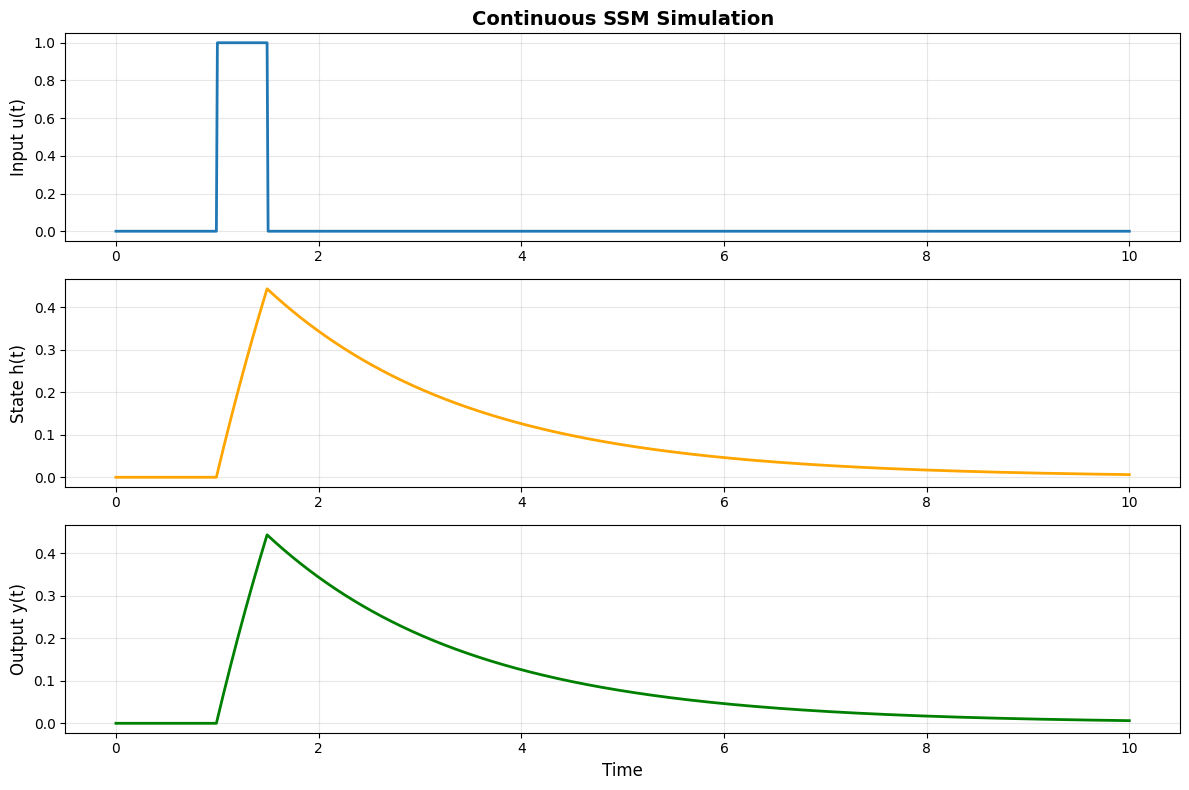

Notice how:
1. The state h(t) accumulates the input (like an RNN's hidden state)
2. When input stops, the state decays (due to negative A)
3. The output y(t) is just a projection of the state


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Simple 1D SSM parameters
A = -0.5  # Decay rate (negative means state decays over time)
B = 1.0   # Input strength
C = 1.0   # Output strength

# Create a simple input signal (a pulse)
t = np.linspace(0, 10, 1000)
u = np.zeros_like(t)
u[100:150] = 1.0  # Pulse from t=1 to t=1.5

# Simulate the SSM using Euler's method
h = np.zeros_like(t)
y = np.zeros_like(t)
dt = t[1] - t[0]

for i in range(1, len(t)):
    h[i] = h[i-1] + dt * (A * h[i-1] + B * u[i])  # h'(t) = A h(t) + B u(t)
    y[i] = C * h[i]  # y(t) = C h(t)

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(t, u, linewidth=2)
axes[0].set_ylabel('Input u(t)', fontsize=12)
axes[0].set_title('Continuous SSM Simulation', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, h, linewidth=2, color='orange')
axes[1].set_ylabel('State h(t)', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, y, linewidth=2, color='green')
axes[2].set_xlabel('Time', fontsize=12)
axes[2].set_ylabel('Output y(t)', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice how:")
print("1. The state h(t) accumulates the input (like an RNN's hidden state)")
print("2. When input stops, the state decays (due to negative A)")
print("3. The output y(t) is just a projection of the state")

## 11. Discretization: From Continuous to Discrete

To use SSMs in deep learning (where we have discrete time steps), we need to **discretize** the continuous equations.

### Discrete-Time SSM

Given a step size `Δ`, we convert:

```
h'(t) = A h(t) + B u(t)
```

Into:

```
h_t = Ā h_{t-1} + B̄ x_t
y_t = C h_t
```

Where `Ā` and `B̄` are discretized versions of `A` and `B`.

### Zero-Order Hold (ZOH) Method

The standard discretization method is:

```
Ā = exp(Δ * A)
B̄ = (Ā - I) / A * B  ≈  Δ * B  (first-order approximation)
```

Let's implement this!

### Discretization Function

This converts continuous SSM parameters to discrete ones.

In [12]:
def discretize(A, B, delta):
    """
    Discretize continuous SSM parameters.
    
    Args:
        A: State transition (scalar or array)
        B: Input projection (scalar or array)
        delta: Time step size
    
    Returns:
        A_bar: Discretized A
        B_bar: Discretized B
    """
    A_bar = torch.exp(delta * A)
    B_bar = delta * B  # First-order approximation
    return A_bar, B_bar

# Test with simple values
A_cont = torch.tensor(-0.5)
B_cont = torch.tensor(1.0)
delta = torch.tensor(0.1)

A_disc, B_disc = discretize(A_cont, B_cont, delta)
print(f"Continuous A: {A_cont.item():.3f}")
print(f"Continuous B: {B_cont.item():.3f}")
print(f"Δ (time step): {delta.item():.3f}")
print(f"\nDiscrete Ā: {A_disc.item():.3f}")
print(f"Discrete B̄: {B_disc.item():.3f}")

Continuous A: -0.500
Continuous B: 1.000
Δ (time step): 0.100

Discrete Ā: 0.951
Discrete B̄: 0.100


### Compare Continuous vs Discrete SSM

Let's verify that our discretization works by comparing continuous and discrete simulations.

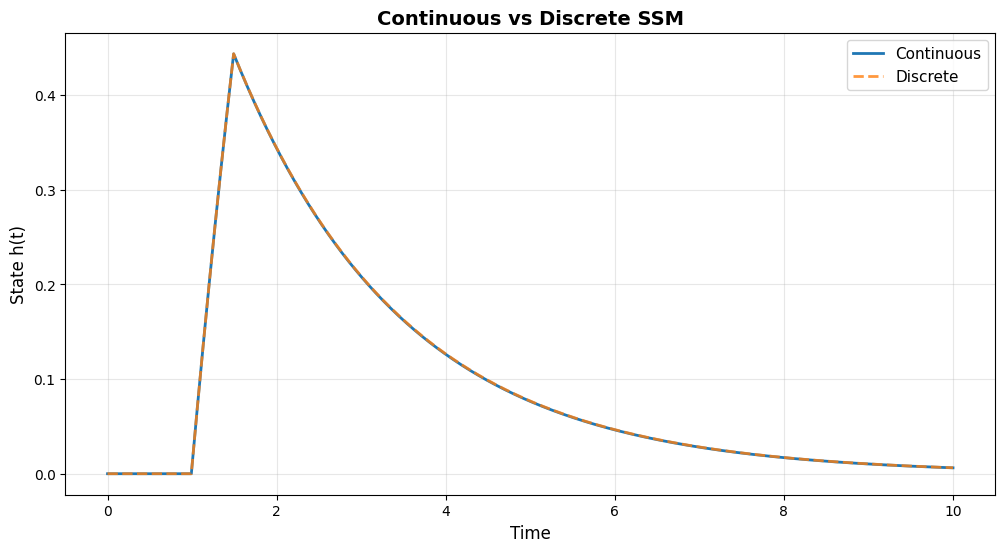

The discrete version closely matches the continuous version!
This validates our discretization approach.


In [13]:
# Continuous simulation (same as before)
A = -0.5
B = 1.0
C = 1.0

t = np.linspace(0, 10, 1000)
u = np.zeros_like(t)
u[100:150] = 1.0

h_cont = np.zeros_like(t)
dt = t[1] - t[0]

for i in range(1, len(t)):
    h_cont[i] = h_cont[i-1] + dt * (A * h_cont[i-1] + B * u[i])

# Discrete simulation
delta = dt
A_bar = np.exp(delta * A)
B_bar = delta * B

h_disc = np.zeros_like(t)
for i in range(1, len(t)):
    h_disc[i] = A_bar * h_disc[i-1] + B_bar * u[i]

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(t, h_cont, label='Continuous', linewidth=2)
plt.plot(t, h_disc, label='Discrete', linewidth=2, linestyle='--', alpha=0.8)
plt.xlabel('Time', fontsize=12)
plt.ylabel('State h(t)', fontsize=12)
plt.title('Continuous vs Discrete SSM', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("The discrete version closely matches the continuous version!")
print("This validates our discretization approach.")

## 12. From Fixed to Selective SSMs

Now we get to the key innovation in Mamba!

### Traditional SSMs: Fixed Parameters

In classical SSMs, the parameters `A`, `B`, `C`, `Δ` are **fixed** - they don't depend on the input.

### Mamba: Selective Parameters

Mamba makes these parameters **input-dependent**:

```python
B = Linear_B(x)         # Input projection depends on input
C = Linear_C(x)         # Output projection depends on input
Δ = Softplus(Linear_Δ(x))  # Time step depends on input
```

**Why is this powerful?**

1. **Filtering**: Make `B` small to ignore irrelevant inputs
2. **Resetting**: Make `Δ` large to "forget" the past
3. **Focus**: Make `C` large to amplify important information

Let's see this in action!

### Visualize Selection Mechanism

Let's create a toy example showing how input-dependent parameters help.

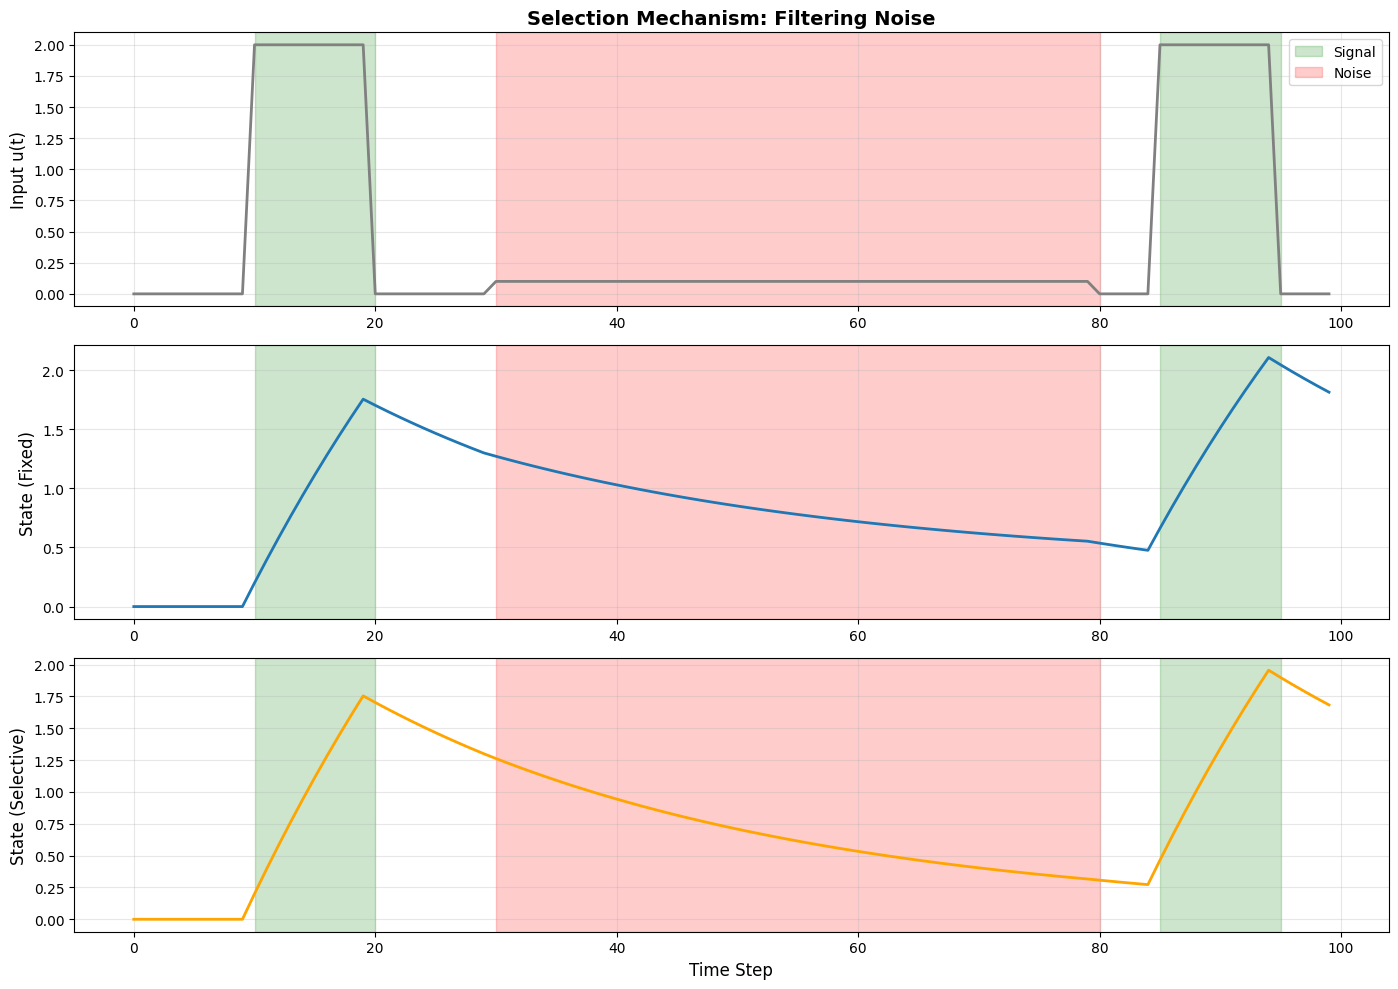

Notice how:
1. Fixed SSM: State gets polluted by noise (middle section)
2. Selective SSM: State ignores noise by making B small!

This is the power of selection: dynamically filtering based on content.


In [14]:
# Create input with "important" and "noise" sections
seq_len = 100
u = np.zeros(seq_len)
u[10:20] = 2.0  # Important signal
u[30:80] = 0.1  # Noise
u[85:95] = 2.0  # Important signal

# Fixed parameters (traditional SSM)
A_fixed = -0.3
B_fixed = 1.0
delta_fixed = 0.1

# Selective parameters (Mamba-style)
# Make B small during noise, large during signal
B_selective = np.ones(seq_len) * 1.0
B_selective[30:80] = 0.1  # Reduce input strength during noise

# Simulate both
A_bar_fixed = np.exp(delta_fixed * A_fixed)
B_bar_fixed = delta_fixed * B_fixed

h_fixed = np.zeros(seq_len)
h_selective = np.zeros(seq_len)

for t in range(1, seq_len):
    # Fixed SSM
    h_fixed[t] = A_bar_fixed * h_fixed[t-1] + B_bar_fixed * u[t]
    
    # Selective SSM (B changes with input)
    B_bar_selective = delta_fixed * B_selective[t]
    h_selective[t] = A_bar_fixed * h_selective[t-1] + B_bar_selective * u[t]

# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(u, linewidth=2, color='gray')
axes[0].set_ylabel('Input u(t)', fontsize=12)
axes[0].set_title('Selection Mechanism: Filtering Noise', fontsize=14, fontweight='bold')
axes[0].axvspan(10, 20, alpha=0.2, color='green', label='Signal')
axes[0].axvspan(30, 80, alpha=0.2, color='red', label='Noise')
axes[0].axvspan(85, 95, alpha=0.2, color='green')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(h_fixed, linewidth=2, label='Fixed SSM')
axes[1].set_ylabel('State (Fixed)', fontsize=12)
axes[1].axvspan(10, 20, alpha=0.2, color='green')
axes[1].axvspan(30, 80, alpha=0.2, color='red')
axes[1].axvspan(85, 95, alpha=0.2, color='green')
axes[1].grid(True, alpha=0.3)

axes[2].plot(h_selective, linewidth=2, color='orange', label='Selective SSM')
axes[2].set_ylabel('State (Selective)', fontsize=12)
axes[2].set_xlabel('Time Step', fontsize=12)
axes[2].axvspan(10, 20, alpha=0.2, color='green')
axes[2].axvspan(30, 80, alpha=0.2, color='red')
axes[2].axvspan(85, 95, alpha=0.2, color='green')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice how:")
print("1. Fixed SSM: State gets polluted by noise (middle section)")
print("2. Selective SSM: State ignores noise by making B small!")
print("\nThis is the power of selection: dynamically filtering based on content.")

## 13. Implement Selective Scan - Step by Step

Now let's build the selective scan function, which is the core of Mamba.

### What is Selective Scan?

It's a recurrent computation where:
1. Parameters `B`, `C`, `Δ` change at each time step (based on input)
2. We discretize using these changing parameters
3. We update the state and compute output

Let's implement this incrementally!

### Step 1: Simple Selective Scan (1D)

Start with a simple 1D version to understand the logic.

In [15]:
def selective_scan_1d(u, delta, A, B, C):
    """
    Simple 1D selective scan for demonstration.
    
    Args:
        u: (seq_len,) input sequence
        delta: (seq_len,) time steps (one per position)
        A: scalar state transition
        B: (seq_len,) input projection (one per position)
        C: (seq_len,) output projection (one per position)
    
    Returns:
        y: (seq_len,) output sequence
    """
    seq_len = len(u)
    h = 0.0  # Hidden state (scalar)
    y = torch.zeros(seq_len)
    
    for t in range(seq_len):
        # Discretize with current delta
        A_bar = torch.exp(delta[t] * A)
        B_bar = delta[t] * B[t]
        
        # Update state
        h = A_bar * h + B_bar * u[t]
        
        # Compute output
        y[t] = C[t] * h
    
    return y

# Test it
seq_len = 10
u = torch.randn(seq_len)
delta = torch.ones(seq_len) * 0.1  # Fixed step size for now
A = torch.tensor(-0.5)
B = torch.ones(seq_len)
C = torch.ones(seq_len)

y = selective_scan_1d(u, delta, A, B, C)
print(f"Input shape: {u.shape}")
print(f"Output shape: {y.shape}")
print(f"\nSuccess! The 1D selective scan works.")

Input shape: torch.Size([10])
Output shape: torch.Size([10])

Success! The 1D selective scan works.


### Step 2: Multi-Dimensional State

Now extend to N-dimensional hidden state (more expressive).

In [16]:
def selective_scan_nd(u, delta, A, B, C):
    """
    Selective scan with N-dimensional state.
    
    Args:
        u: (seq_len,) input sequence (scalar at each position)
        delta: (seq_len,) time steps
        A: (state_size,) state transition parameters
        B: (seq_len, state_size) input projection
        C: (seq_len, state_size) output projection
    
    Returns:
        y: (seq_len,) output sequence
    """
    seq_len = len(u)
    state_size = A.shape[0]
    
    h = torch.zeros(state_size)  # N-dimensional state
    y = torch.zeros(seq_len)
    
    for t in range(seq_len):
        # Discretize (A is a vector, so this is element-wise)
        A_bar = torch.exp(delta[t] * A)  # (state_size,)
        B_bar = delta[t] * B[t]  # (state_size,)
        
        # Update state (element-wise)
        h = A_bar * h + B_bar * u[t]  # (state_size,)
        
        # Compute output (dot product)
        y[t] = (C[t] * h).sum()  # Scalar
    
    return y

# Test it
seq_len = 10
state_size = 4

u = torch.randn(seq_len)
delta = torch.ones(seq_len) * 0.1
A = torch.randn(state_size) * (-1.0)  # Negative for stability
B = torch.randn(seq_len, state_size)
C = torch.randn(seq_len, state_size)

y = selective_scan_nd(u, delta, A, B, C)
print(f"Input shape: {u.shape}")
print(f"State size: {state_size}")
print(f"Output shape: {y.shape}")
print(f"\nSuccess! Multi-dimensional state works.")

Input shape: torch.Size([10])
State size: 4
Output shape: torch.Size([10])

Success! Multi-dimensional state works.


### Step 3: Batch and Multi-Channel Support

Finally, add batch and multiple channels (d_inner) support for the full implementation.

In [17]:
def selective_scan(u, delta, A, B, C):
    """
    Full selective scan with batches and channels.
    
    Args:
        u: (batch, seq_len, d_inner) input
        delta: (batch, seq_len, d_inner) time steps
        A: (d_inner, d_state) state parameters (in log space)
        B: (batch, seq_len, d_state) input projection
        C: (batch, seq_len, d_state) output projection
    
    Returns:
        y: (batch, seq_len, d_inner) output
    """
    batch, seq_len, d_inner = u.shape
    d_state = A.shape[1]
    
    # Expand A for broadcasting: (1, 1, d_inner, d_state)
    A = A.unsqueeze(0).unsqueeze(0)
    
    # Compute discretized A for all positions
    # delta: (batch, seq_len, d_inner) -> (batch, seq_len, d_inner, 1)
    # A: (1, 1, d_inner, d_state)
    # Result: (batch, seq_len, d_inner, d_state)
    delta_A = delta.unsqueeze(-1) * A
    A_bar = torch.exp(delta_A)
    
    # Compute discretized B * u
    # delta: (batch, seq_len, d_inner, 1)
    # B: (batch, seq_len, 1, d_state)
    # u: (batch, seq_len, d_inner, 1)
    delta_B_u = delta.unsqueeze(-1) * B.unsqueeze(2) * u.unsqueeze(-1)
    # Result: (batch, seq_len, d_inner, d_state)
    
    # Initialize state
    h = torch.zeros(batch, d_inner, d_state, device=u.device, dtype=u.dtype)
    y = torch.zeros(batch, seq_len, d_inner, device=u.device, dtype=u.dtype)
    
    # Recurrent scan
    for t in range(seq_len):
        h = A_bar[:, t] * h + delta_B_u[:, t]  # (batch, d_inner, d_state)
        y[:, t] = (h * C[:, t].unsqueeze(1)).sum(dim=-1)  # (batch, d_inner)
    
    return y

# Test it with realistic dimensions
batch = 2
seq_len = 8
d_inner = 4
d_state = 6

u = torch.randn(batch, seq_len, d_inner)
delta = torch.ones(batch, seq_len, d_inner) * 0.1
A = torch.randn(d_inner, d_state) * (-1.0)
B = torch.randn(batch, seq_len, d_state)
C = torch.randn(batch, seq_len, d_state)

y = selective_scan(u, delta, A, B, C)
print(f"Input shape: {u.shape}")
print(f"Output shape: {y.shape}")
print(f"\nOutput preserves shape: {u.shape == y.shape}")
print(f"\nFull selective scan implementation complete!")

Input shape: torch.Size([2, 8, 4])
Output shape: torch.Size([2, 8, 4])

Output preserves shape: True

Full selective scan implementation complete!


## 14. Build the Mamba Block

Now we can assemble everything into a Mamba block!

### Architecture Recap

```
Input x → Linear projection (split into x and z)
       ↓
x → Conv1d (local context)
  → SiLU activation
  → Compute selective params (B, C, Δ) from x
  → Selective scan with data-dependent params
  → Multiply by gate (z)
  → Linear projection back to d_model
```

Let's implement this piece by piece.

### Mamba Block Implementation

This is the main building block of the Mamba model.

In [18]:
class MambaBlock(nn.Module):
    """A single Mamba block with selective SSM."""
    
    def __init__(
        self, 
        d_model, 
        d_state=16, 
        expand=2, 
        conv_kernel=4
    ):
        super().__init__()

        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = d_model * expand  # Expanded dimension
        self.conv_kernel = conv_kernel
        
        # 1. Input projection (to 2*d_inner for x and z)
        self.in_proj = nn.Linear(d_model, 2 * self.d_inner, bias=False)
        
        # 2. Convolution (adds local context within sequence)
        # This is for doing temporal mixing across each channel independently (no mixing between channels)
        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner,
            out_channels=self.d_inner,
            kernel_size=conv_kernel,
            padding=conv_kernel - 1,
            groups=self.d_inner  # Depthwise convolution
        )
        
        # 3. SSM parameters
        # A: Initialize as diagonal matrix (S4D-Lin initialization)
        # TODO: what is this?
        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        # TODO: why the log?
        self.A_log = nn.Parameter(torch.log(A))  # Log space for stability
        
        # 4. Projection to compute selective parameters B, C, Δ
        self.x_proj = nn.Linear(
            self.d_inner,
            d_state * 2 + 1,  # B (d_state) + C (d_state) + Δ (1)
            bias=False
        )
        
        # 5. Output projection
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
    
    def _forward(self, x):
        """
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            output: (batch, seq_len, d_model)
        """
        B, T, C = x.shape
        
        # Step 1: Project and split into x and z (for gating)
        x_and_z = self.in_proj(x)  # (B, T, C * 2)
        x, z = x_and_z.chunk(2, dim=-1)  # Each: (B, T, C)
        
        # Step 2: Apply convolution for local context
        # Conv1d expects (batch, channels, seq_len)
        x_conv = x.transpose(1, 2) # (B, C, T)
        x_conv = self.conv1d(x)  # (B, C, T + P)
        x_conv = x_conv[:, :, :T] # (B, C, T)
        x_conv = x_conv.transpose(1, 2)  # (B, T, C)
        
        # Step 3: Activation
        x_conv = F.silu(x_conv)
        
        # Step 4: Compute selective parameters from input
        ssm_params = self.x_proj(x_conv)  # (B, T, C) (B, T, 2 * S + 1) ... (2 * S + 1) = B (d_state) + C (d_state) + Δ (1)
        delta, B, C = torch.split(
            ssm_params,
            [1, self.d_state, self.d_state],
            dim=-1
        )
        # delta: (B, T, 1)
        # B, C: (B, T, S)
        
        # Step 5: Ensure delta is positive and expand to d_inner
        delta = F.softplus(delta)  # (B, T, 1)
        delta = delta.expand(-1, -1, self.d_inner)  # (B, T, I)
        
        # Step 6: Selective scan
        A = -torch.exp(self.A_log)  # Negative for stability
        y = selective_scan(x_conv, delta, A, B, C) # (B, T, C) -> (B, T, I)
        # y: (B, T, d_inner)
        
        # Step 7: Gating (multiply by activated z)
        y = y * F.silu(z)
        
        # Step 8: Project back to model dimension
        output = self.out_proj(y)
        return output

    def forward(self, x, states=None):
        """
        Forward pass with selective scan written explicitly in Python.
        Every line is commented to explain what it does and why.

        Args:
            x: (B, T, d_model) input tensor
            states: Optional previous hidden states (B, I, S). If None, starts from zeros.

        Returns:
            output: (B, T, d_model) output tensor
            new_states: (B, I, S) final hidden states
        """

        # x: (B, T, d_model)
        B, T, _ = x.shape           # Extract batch size and sequence length
        I = self.d_inner            # Expanded channel dimension
        S = self.d_state            # Number of SSM state dimensions

        # ------------------------------------------------------------
        # Step 1: Input projection and gating split
        # ------------------------------------------------------------

        # (B, T, d_model) -> (B, T, 2I)
        # Project input into two streams:
        #   - one for SSM processing (x)
        #   - one for gating (z)
        x_and_z = self.in_proj(x)

        # (B, T, 2I) -> (B, T, I), (B, T, I)
        # Split projected features into SSM input (x) and gate (z)
        x, z = x_and_z.chunk(2, dim=-1)

        # ------------------------------------------------------------
        # Step 2: Depthwise convolution (local temporal mixing)
        # ------------------------------------------------------------

        # (B, T, I) -> (B, I, T)
        # Conv1d expects channels-first layout
        x_conv = x.transpose(1, 2)

        # (B, I, T) -> (B, I, T + padding)
        # Apply depthwise convolution independently per channel
        x_conv = self.conv1d(x_conv)

        # (B, I, T + padding) -> (B, I, T)
        # Remove extra padded positions to preserve sequence length
        x_conv = x_conv[:, :, :T]

        # (B, I, T) -> (B, T, I)
        # Return to sequence-major layout
        x_conv = x_conv.transpose(1, 2)

        # ------------------------------------------------------------
        # Step 3: Nonlinearity
        # ------------------------------------------------------------

        # (B, T, I) -> (B, T, I)
        # Smooth activation improves stability of SSM parameter generation
        x_conv = F.silu(x_conv)

        # ------------------------------------------------------------
        # Step 4: Generate selective SSM parameters
        # ------------------------------------------------------------

        # (B, T, I) -> (B, T, 2S + 1)
        # Compute time-dependent SSM parameters:
        #   delta (Δ), B, and C
        ssm_params = self.x_proj(x_conv)

        # Split parameters:
        #   delta: step size Δ(t)
        #   B_param: input projection coefficients
        #   C_param: output projection coefficients
        # Shapes:
        #   delta:   (B, T, 1)
        #   B_param: (B, T, S)
        #   C_param: (B, T, S)
        delta, B_param, C_param = torch.split(
            ssm_params, [1, S, S], dim=-1
        )

        # ------------------------------------------------------------
        # Step 5: Delta (step size) processing
        # ------------------------------------------------------------

        # (B, T, 1) -> (B, T, 1)
        # Ensure step size is positive for stable discretization
        delta = F.softplus(delta)

        # (B, T, 1) -> (B, T, I)
        # Broadcast step size across all channels
        delta = delta.expand(-1, -1, I)

        # ------------------------------------------------------------
        # Step 6: Prepare the SSM transition matrix A
        # ------------------------------------------------------------

        # (I, S) -> (I, S)
        # Convert log-parameterized A to real space
        # Negative sign ensures stable (decaying) dynamics
        A = -torch.exp(self.A_log)

        # ------------------------------------------------------------
        # Step 7: Initialize scan state and output buffer
        # ------------------------------------------------------------

        # (B, I, S)
        # Hidden state for each batch and channel
        # Use provided states or initialize to zeros
        if states is None:
            h = torch.zeros(B, I, S, device=x.device, dtype=x.dtype)
        else:
            h = states

        # (B, T, I)
        # Output tensor for the full sequence
        y = torch.zeros(B, T, I, device=x.device, dtype=x.dtype)

        # ------------------------------------------------------------
        # Step 8: Selective scan (SSM recurrence over time)
        # ------------------------------------------------------------

        for t in range(T):
            # Extract delta for time step t
            # (B, I) -> (B, I, 1)
            delta_t = delta[:, t, :].unsqueeze(-1)

            # Discretize continuous-time dynamics:
            # exp(A * delta_t)
            # (I, S) -> (1, I, S) -> (B, I, S)
            A_disc = torch.exp(A.unsqueeze(0) * delta_t)

            # Extract input at time step t
            # (B, I) -> (B, I, 1)
            x_t = x_conv[:, t].unsqueeze(-1)

            # Extract input projection coefficients
            # (B, S) -> (B, 1, S)
            B_t = B_param[:, t].unsqueeze(1)

            # State update:
            # h_t = exp(A * Δ_t) ⊙ h_{t-1} + B_t ⊙ x_t
            # (B, I, S)
            h = A_disc * h + B_t * x_t

            # Extract output projection coefficients
            # (B, S) -> (B, 1, S)
            C_t = C_param[:, t].unsqueeze(1)

            # Project hidden state to output
            # (B, I, S) -> (B, I)
            y[:, t] = torch.sum(C_t * h, dim=-1)

        # ------------------------------------------------------------
        # Step 9: Gating
        # ------------------------------------------------------------

        # (B, T, I) * (B, T, I) -> (B, T, I)
        # Gate SSM output using a smooth, learned gate
        y = y * F.silu(z)

        # ------------------------------------------------------------
        # Step 10: Output projection
        # ------------------------------------------------------------

        # (B, T, I) -> (B, T, d_model)
        # Return to model dimension
        return self.out_proj(y), h
        
print("MambaBlock implementation complete!")

MambaBlock implementation complete!


### Test Mamba Block

Verify that the block works with our chosen dimensions.

In [19]:
# Create a test block
mamba_block = MambaBlock(
    d_model=CONFIG["hidden_size"],
    d_state=CONFIG["state_size"],
    expand=CONFIG["expand_factor"]
)

# Test with random input
test_x = torch.randn(2, 10, CONFIG["hidden_size"])  # (batch=2, seq=10, d_model)
test_y, test_states = mamba_block(test_x)

print(f"Input shape: {test_x.shape}")
print(f"Output shape: {test_y.shape}")
print(f"States shape: {test_states.shape}")
print(f"Shape preserved: {test_x.shape == test_y.shape}")

# Count parameters
n_params = sum(p.numel() for p in mamba_block.parameters())
print(f"\nParameters in one Mamba block: {n_params:,}")

Input shape: torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])
States shape: torch.Size([2, 128, 4])
Shape preserved: True

Parameters in one Mamba block: 26,880


## 15. Add Residual Connection and LayerNorm

Like transformers, we'll wrap our Mamba block with normalization and residual connections.

In [20]:
class ResidualMambaBlock(nn.Module):
    """Mamba block with pre-norm and residual connection."""
    
    def __init__(self, d_model, d_state=16, expand=2):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.mamba = MambaBlock(d_model, d_state, expand)
    
    def forward(self, x, states=None):
        """
        Args:
            x: (B, T, d_model) input tensor
            states: Optional previous hidden states for the mamba block

        Returns:
            output: (B, T, d_model) output tensor
            new_states: New hidden states from the mamba block
        """
        # Pre-norm with residual: x + Mamba(LayerNorm(x))
        mamba_out, new_states = self.mamba(self.norm(x), states)
        return x + mamba_out, new_states

print("ResidualMambaBlock implementation complete!")

ResidualMambaBlock implementation complete!


## 16. Build the Full Mamba Model

Stack multiple Mamba blocks to create the complete language model.

In [21]:
class Mamba(nn.Module):
    """Full Mamba language model."""
    
    def __init__(
        self,
        vocab_size,
        n_embed,
        d_model,
        d_state,
        n_layers,
        expand
    ):
        super().__init__()
        
        # Token embeddings
        self.embeddings = nn.Embedding(vocab_size, n_embed)
        
        # Project to model dimension if needed
        self.embed_proj = (
            nn.Linear(n_embed, d_model, bias=False)
            if n_embed != d_model
            else nn.Identity()
        )
        
        # Stack of Mamba blocks
        self.blocks = nn.ModuleList([
            ResidualMambaBlock(d_model, d_state, expand)
            for _ in range(n_layers)
        ])
        
        # Output head
        self.ln_out = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
    
    def forward(self, x, states=None):
        """
        Args:
            x: (batch, seq_len) token indices
            states: Optional list of previous hidden states for each layer.
                    If None, all layers start from zeros.
                    If provided, should be a list of length n_layers.

        Returns:
            logits: (batch, seq_len, vocab_size)
            new_states: List of new hidden states for each layer
        """
        # Embed tokens
        x = self.embeddings(x)  # (batch, seq_len, n_embed)
        x = self.embed_proj(x)  # (batch, seq_len, d_model)
        
        # Initialize states list if not provided
        if states is None:
            states = [None] * len(self.blocks)
        
        # Pass through Mamba blocks and collect new states
        new_states = []
        for i, block in enumerate(self.blocks):
            x, layer_state = block(x, states[i])
            new_states.append(layer_state)
        
        # Output projection
        x = self.ln_out(x)
        logits = self.head(x)  # (batch, seq_len, vocab_size)
        
        return logits, new_states

print("Full Mamba model implementation complete!")

Full Mamba model implementation complete!


### Initialize the Model

Create our Mamba model with the configuration we set at the beginning.

In [22]:
model = Mamba(
    vocab_size=CONFIG["vocab_size"],
    n_embed=CONFIG["n_embed"],
    d_model=CONFIG["hidden_size"],
    d_state=CONFIG["state_size"],
    n_layers=CONFIG["n_layers"],
    expand=CONFIG["expand_factor"]
).to(DEVICE)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

# Test forward pass (model now returns logits and states)
x_test, _ = next(iter(train_loader))
x_test = x_test.to(DEVICE)
logits, states = model(x_test)

print(f"\nInput shape: {x_test.shape}")
print(f"Output shape: {logits.shape}")
print(f"Number of layer states: {len(states)}")
print(f"Each state shape: {states[0].shape}")
print(f"Expected: (batch={CONFIG['batch_size']}, seq={CONFIG['block_size']}, vocab={CONFIG['vocab_size']})")

Total parameters: 36,576

Input shape: torch.Size([16, 128])
Output shape: torch.Size([16, 128, 77])
Number of layer states: 1
Each state shape: torch.Size([16, 128, 4])
Expected: (batch=16, seq=128, vocab=77)


## 17. Implement Evaluation Function

Before training, let's create a function to evaluate the model on validation data.

In [23]:
from tqdm import tqdm

@torch.no_grad()
def evaluate(model, loader):
    """Compute average loss on a dataset."""
    model.eval()
    losses = []
    
    device = next(model.parameters()).device
    for x, y in tqdm(loader, desc="Evaluating", disable=True):
        x, y = x.to(device), y.to(device)
        
        # Forward pass (model now returns logits and states)
        logits, _ = model(x)  # (batch, seq_len, vocab_size)
        logits = logits.reshape(-1, logits.size(-1))  # (batch*seq_len, vocab_size)
        y = y.reshape(-1)  # (batch*seq_len,)
        
        # Compute loss
        loss = F.cross_entropy(logits, y)
        losses.append(loss.item())
    
    return sum(losses) / len(losses)

# Test evaluation
initial_loss = evaluate(model, val_loader)
random_loss = torch.log(torch.tensor(CONFIG["vocab_size"])).item()

print(f"Initial validation loss: {initial_loss:.4f}")
print(f"Random guess loss (log({CONFIG['vocab_size']})): {random_loss:.4f}")
print(f"\nThe model should start near random guess loss.")

Initial validation loss: 4.4735
Random guess loss (log(77)): 4.3438

The model should start near random guess loss.


## 18. Training Loop

Now let's train the model! We'll use early stopping to avoid overfitting.

In [24]:
import time
import torch.optim

# Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
train_losses = []
val_losses = []
patience = CONFIG["max_patience"]
best_val_loss = float('inf')

print("Starting training...\n")
start_time = time.time()

for epoch in range(CONFIG["n_epochs"]):
    model.train()
    epoch_losses = []
    
    # Training loop
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['n_epochs']}")
    for x, y in pbar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        # Forward pass (model now returns logits and states)
        logits, _ = model(x)
        logits = logits.reshape(-1, logits.size(-1))
        y = y.reshape(-1)
        loss = F.cross_entropy(logits, y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
        pbar.set_postfix({"train_loss": loss.item()})
    
    # Compute metrics
    train_loss = sum(epoch_losses) / len(epoch_losses)
    val_loss = evaluate(model, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
    
    # Early stopping
    val_improvement = best_val_loss - val_loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        if val_improvement > CONFIG["early_stop_threshold"]:
            patience = CONFIG["max_patience"]  # Significant improvement
        else:
            patience -= 1  # Small improvement
    else:
        patience -= 1  # No improvement
    
    print(f"  → Patience: {patience}/{CONFIG['max_patience']}")
    
    if patience == 0:
        print("\nEarly stopping triggered!")
        break

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed:.1f}s")
print(f"Best validation loss: {best_val_loss:.4f}")

Starting training...



Epoch 1/5: 100%|██████████| 1280/1280 [01:32<00:00, 13.84it/s, train_loss=1.61]


Epoch 1: train_loss=1.8623, val_loss=1.6759
  → Patience: 2/2


Epoch 2/5: 100%|██████████| 1280/1280 [01:32<00:00, 13.89it/s, train_loss=1.62]


Epoch 2: train_loss=1.6536, val_loss=1.6257
  → Patience: 2/2


...

Epoch 3: train_loss=1.6170, val_loss=1.6081
  → Patience: 2/2


Epoch 4/5: 100%|██████████| 1280/1280 [01:25<00:00, 14.91it/s, train_loss=1.6] 


Epoch 4: train_loss=1.5959, val_loss=1.5872
  → Patience: 2/2


Epoch 5/5:  63%|██████▎   | 808/1280 [00:54<00:32, 14.72it/s, train_loss=1.6] 


KeyboardInterrupt: 

## 19. Plot Training Curves

Visualize how the model learned over time.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Train Loss', marker='o', linewidth=2, color='#4ECDC4')
plt.plot(val_losses, label='Validation Loss', marker='s', linewidth=2, color='#FF6B6B')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Mamba Training Progress', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Report statistics
best_epoch = val_losses.index(min(val_losses)) + 1
print(f"Best validation loss: {min(val_losses):.4f} at epoch {best_epoch}")
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")

## 20. Text Generation

Now let's test our trained model by generating text!

In [71]:
def generate(model, prompt, max_len=100, temperature=1.0, use_states=True):
    """
    Generate text continuation from a prompt.
    
    Args:
        model: The trained model
        prompt: Starting text
        max_len: Maximum total length
        temperature: Sampling temperature (lower = more conservative)
        use_states: If True, maintain states across tokens (correct behavior)
                    If False, reset states each token (for comparison)
    """
    model.eval()
    device = next(model.parameters()).device

    tokens = encode(prompt)
    max_new = max_len - len(tokens)

    print(prompt, end="", flush=True)

    def sample(logits):
        logits = logits[:, -1] / temperature
        probs = F.softmax(logits, dim=-1)
        return torch.multinomial(probs, 1).item()

    start_time = time.perf_counter()
    generated = 0

    with torch.no_grad():
        # Initial forward pass with prompt
        x = torch.tensor(tokens).unsqueeze(0).to(device)
        logits, states = model(x)

        for _ in range(max_new):
            # Sample next token
            t = sample(logits)
            tokens.append(t)
            generated += 1
            print(decode([t]), end="", flush=True)

            # Generate next token
            x = torch.tensor([[t]], device=device)
            if use_states:
                # Correct: maintain context across tokens
                logits, states = model(x, states)
            else:
                # Incorrect: reset states (loses context!)
                logits, states = model(x)

    elapsed = time.perf_counter() - start_time
    tps = generated / elapsed if elapsed > 0 else 0.0

    print(f"\n\n[{'WITH' if use_states else 'WITHOUT'} states] "
          f"Generated {generated} tokens in {elapsed:.2f}s ({tps:.2f} tokens/sec)")

print("Generation function ready!")
print("\nNOTE: use_states=True maintains context (correct)")
print("      use_states=False resets states each token (for comparison)")

Generation function ready!

NOTE: use_states=True maintains context (correct)
      use_states=False resets states each token (for comparison)


### Generate Sample 1

Try generating text about Frodo.

In [72]:
import time

prompt = "frodo picked up the "

print("=" * 70)
print("1. WITH states (correct - maintains context)")
print("=" * 70)
generate(model, prompt, max_len=50, temperature=1.0, use_states=True)

print("\n" + "=" * 70)
print("2. WITHOUT states (incorrect - loses context)")
print("=" * 70)
generate(model, prompt, max_len=50, temperature=1.0, use_states=False)

print("\n" + "=" * 70)
print("COMPARISON:")
print("- Speed should be similar (both process 1 token at a time)")
print("- Quality might differ (with states maintains context)")
print("=" * 70)

1. WITH states (correct - maintains context)
frodo picked up the th win t ning g p t satrun ghy

[WITH states] Generated 30 tokens in 0.22s (133.54 tokens/sec)

2. WITHOUT states (incorrect - loses context)
frodo picked up the s! ft t guraicerusthoms?' itut

[WITHOUT states] Generated 30 tokens in 0.21s (145.78 tokens/sec)

COMPARISON:
- Speed should be similar (both process 1 token at a time)
- Quality might differ (with states maintains context)


### Compare: With vs Without States

Let's generate the same prompt twice to see the difference in quality (not speed).

In [69]:
generate(model, "frodo picked up the ", max_len=500, temperature=1.0)

frodo picked up the w the heved authawas t outse wen's al sins s clas t, agoversus y d s taur rs ines theren's we ed wlomo bu fres the witwas toowar ce at tingoromeellyous lyot blalle f te t thelthe nd wanthie tly d, haly watho h a towiriren. suleves sel s? thes, bed d thes t horininthartinmbus thare icring intaningr. telomowarorst owalered feg amatles wend. a thel we males?" hes breseves tweren menghesmed fort asas he alamboures ired d, was sorie ta toly; imagure t nd any andaglmarest, wagus th

Generated 480 tokens in 2.78s (172.81 tokens/sec)


### Generate Sample 2

Try a different prompt about Gandalf.

In [ ]:
generate(model, "gandalf said ", max_len=100, temperature=1.0)

### Generate with Lower Temperature

Use lower temperature for more focused, conservative text.

In [ ]:
generate(model, "the ring of power ", max_len=100, temperature=0.7)

## 21. Key Takeaways

Congratulations! You've built Mamba from scratch. Let's recap what we learned.

### Core Concepts

1. **State Space Models (SSMs)** come from control theory and model sequences through continuous state evolution

2. **Discretization** converts continuous SSMs to discrete time steps using the zero-order hold method

3. **Selection mechanism** is the key innovation: making parameters (B, C, Δ) input-dependent allows:
   - **Filtering** irrelevant information (small B)
   - **Resetting** state when needed (large Δ)
   - **Focusing** on important features (large C)

4. **Selective scan** processes sequences recurrently with data-dependent dynamics

### Architecture Components

- **Input projection** splits into pathway (x) and gate (z)
- **Convolution** adds local context
- **Parameter computation** generates B, C, Δ from input
- **Selective scan** processes with data-dependent SSM
- **Gating** modulates output
- **Residual connections** and layer normalization for stability

### Comparison to Other Models

| Model | Complexity | Mechanism | Parameters |
|-------|-----------|-----------|------------|
| RNN | O(T) | Recurrent | Fixed |
| Transformer | O(T²) | Attention | Fixed |
| RWKV | O(T) | Linear Attention | Mixed |
| **Mamba** | O(T) | **Selective SSM** | **Data-dependent** |

### Why This Matters

Mamba demonstrates that:
- **Linear complexity** doesn't mean sacrificing expressiveness
- **Selection** (content-based parameter adjustment) is powerful
- Classical control theory concepts can be adapted for modern deep learning

### Going Further

To deepen your understanding:
1. Compare with the RWKV notebook - how do their approaches differ?
2. Visualize the learned Δ, B, C parameters to understand what the model selects
3. Implement the hardware-efficient parallel scan algorithm
4. Scale to larger models and longer sequences
5. Try different tasks (image sequences, audio, etc.)